# Energy Thief — Level 2: Tabular Q-Learning vs Linear Function Approximation

**Project VFA-4.** Same power grid as Level 1 — a plant feeding **consumers** through
substations; the thief **skims** a line's slack or **overdraws** into delivered demand —
but on a **bigger network** with the brief's **adaptive monitoring**:

1. the plant feeds **two substations**, one watched more closely than the other;
2. every consumer edge carries a **suspicion** ("heat") that **rises when tapped** and
   **cools when idle**, inflating that edge's alarm probability.

Suspicion enters the state, so the state space **explodes** to 26,244. This notebook runs
**tabular Q-learning** (which strains — most of the table is never visited) and then
**linear function approximation** with hand-crafted features (which *generalises* across
the many near-identical states), and compares them.

## The MDP

Finite MDP on a plant → **two substations** → $n=6$ consumers (three each). One substation
is monitored more closely (factor $m_{\text{sub}(c)}$). Each consumer edge $c$ has flow
$f_c$, slack $s_c$ (a function of the demand phase $\phi$), and a **suspicion**
$\sigma_c \in \{0,\dots,k-1\}$.

**State space.** $s = (\phi, U, \sigma_1,\dots,\sigma_6)$, $|\mathcal{S}| = n_\phi(U_{\max}+1)k^{n} = 4\cdot 9\cdot 3^6 = 26{,}244$ (vs 36 at L1). The exponential $k^n$ is the curse.

**Actions.** Skim / overdraw each edge, or lie-low: $|\mathcal{A}| = 2n+1 = 13$.

**Transitions.** Phase random walk; a tap diverts slack (overdraw adds a shortfall $h$);
alarm with $p = \varsigma(\phi)\,m_{\text{sub}(c)}\,(1+1.5h)\,(1+\sigma_c)$; the tap raises
$\sigma_c$, other edges cool. **Reward** $R=U'$ (surplus held); an alarm resets $U\to0$.
$T=50$, $\gamma=0.99$.

*Units.* Energy in **MW** (1 unit = 5 MW; surplus cap = 40 MW); return in **MWh**.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

from energy_thief.envs import GridThiefEnvL2, ACTION_NAMES_L2
from energy_thief.agents import QLearningAgent, LinearQLearningAgent

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110
MW = 5

In [2]:
env = GridThiefEnvL2(seed=1)
print(f"states: {env.n_states}   actions: {env.n_actions}")
for s in range(env.n_substations):
    members = [env.consumers[i] for i in range(env.n_consumers) if env.substation_of[i] == s]
    print(f"  {env.substations[s]} (monitoring x{env.substation_sens[s]:g}): {members}")
print(f"suspicion levels k = {env.k};  |S| = {env.n_phase} x {env.surplus_max+1} x {env.k}^{env.n_consumers} = {env.n_states}")
print(env.render())

states: 26244   actions: 13
  S1 (monitoring x1): ['C1', 'C2', 'C3']
  S2 (monitoring x1.3): ['C4', 'C5', 'C6']
suspicion levels k = 3;  |S| = 4 x 9 x 3^6 = 26244
t=0   phase=0 surplus=0/8  heat[C10 C20 C30 C40 C50 C60]  [S1:C1C2C3  S2:C4C5C6]


## The environment

**Left:** the network — a plant feeds **two substations**, each serving three consumers;
**S2 is monitored more closely** ($\times 1.3$). **Middle:** the divertible **slack** on
each edge per demand phase (in MW). **Right:** the Level-2 twist — suspicion multiplies an
**overdraw**'s alarm probability by $(1+\sigma)$, so an edge tapped repeatedly becomes
almost certain to trip the alarm, forcing the thief to **spread its taps**.

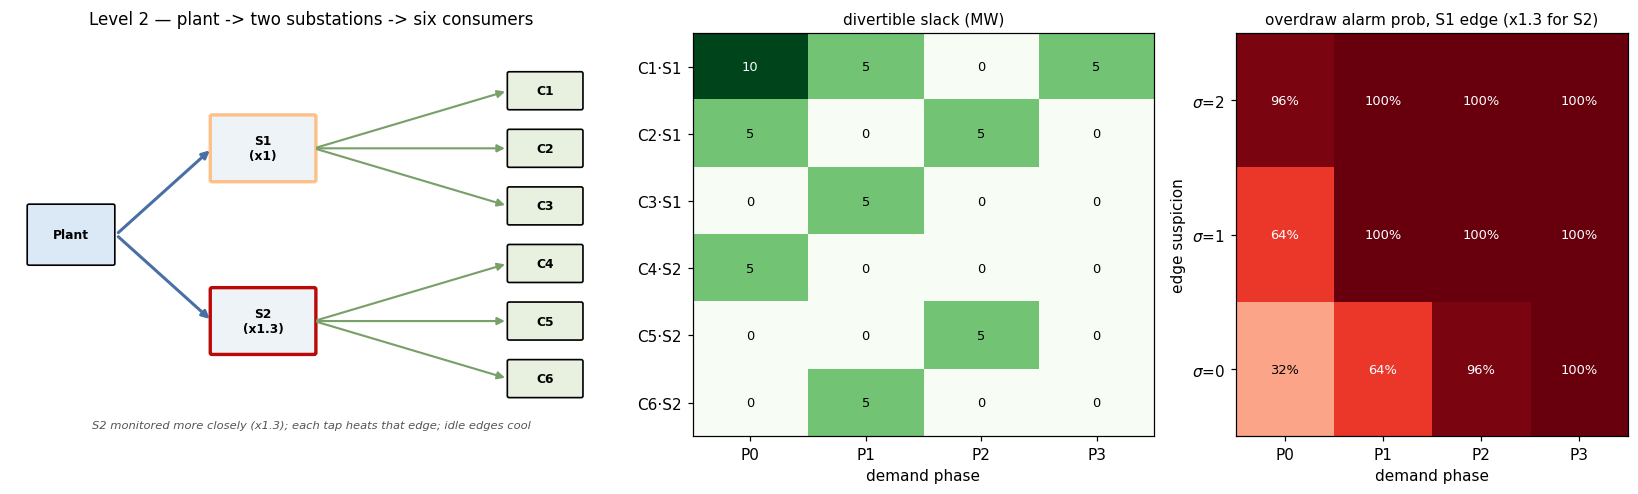

In [3]:
fig, (axS, axK, axH) = plt.subplots(1, 3, figsize=(15, 4.6),
                                    gridspec_kw={"width_ratios": [1.3, 1, 0.85]})
n = env.n_consumers
axS.set_xlim(0, 10); axS.set_ylim(0, n + 1.0); axS.axis("off")
def boxS(x, y, w, h, label, fc, ec="black", lw=1.1):
    axS.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.03", fc=fc, ec=ec, lw=lw))
    axS.text(x, y, label, ha="center", va="center", fontsize=8, weight="bold")
cons_y = {i: n - i for i in range(n)}; ymid = (n + 1.0) / 2
boxS(1.0, ymid, 1.4, 1.0, "Plant", "#dbe9f6")
sub_cmap = plt.get_cmap("OrRd"); maxf = max(env.substation_sens)
for s in range(env.n_substations):
    members = [i for i in range(n) if env.substation_of[i] == s]
    sy = float(np.mean([cons_y[i] for i in members])); factor = env.substation_sens[s]
    ec = sub_cmap(0.35 + 0.5 * (factor - 1) / max(1e-9, maxf - 1))
    boxS(4.2, sy, 1.7, 1.1, f"{env.substations[s]}\n(x{factor:g})", "#eef3f8", ec=ec, lw=2.2)
    axS.annotate("", xy=(3.35, sy), xytext=(1.75, ymid), arrowprops=dict(arrowstyle="-|>", lw=2.0, color="#4a6fa5"))
    for i in members:
        boxS(8.9, cons_y[i], 1.2, 0.6, env.consumers[i], "#e8f0e0")
        axS.annotate("", xy=(8.28, cons_y[i]), xytext=(5.05, sy), arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#7aa06a"))
axS.set_title("Level 2 — plant -> two substations -> six consumers", fontsize=11)
axS.text(5.0, 0.15, "S2 monitored more closely (x1.3); each tap heats that edge; idle edges cool", ha="center", fontsize=7.5, style="italic", color="#555")

axK.imshow(env.slack.T, cmap="Greens", aspect="auto", vmin=0, vmax=max(1, env.slack.max()))
for i in range(n):
    for ph in range(env.n_phase):
        axK.text(ph, i, str(env.slack[ph, i]*MW), ha="center", va="center", fontsize=8.5,
                 color="white" if env.slack[ph, i] > env.slack.max()*0.6 else "black")
axK.set_xticks(range(env.n_phase)); axK.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axK.set_yticks(range(n)); axK.set_yticklabels([f"{env.consumers[i]}·{env.substations[env.substation_of[i]]}" for i in range(n)])
axK.set_xlabel("demand phase"); axK.set_title("divertible slack (MW)", fontsize=10)

sus_risk = np.array([[min(1.0, env.sens[ph] * (env.base_divert + env.shortfall_weight * env.overdraw_extra) * (1 + env.susp_factor * s))
                      for ph in range(env.n_phase)] for s in range(env.k)])
axH.imshow(sus_risk, cmap="Reds", aspect="auto", vmin=0, vmax=1, origin="lower")
for s in range(env.k):
    for ph in range(env.n_phase):
        axH.text(ph, s, f"{sus_risk[s, ph]*100:.0f}%", ha="center", va="center", fontsize=8.5,
                 color="white" if sus_risk[s, ph] > 0.5 else "black")
axH.set_xticks(range(env.n_phase)); axH.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axH.set_yticks(range(env.k)); axH.set_yticklabels([f"$\\sigma$={s}" for s in range(env.k)])
axH.set_xlabel("demand phase"); axH.set_ylabel("edge suspicion")
axH.set_title("overdraw alarm prob, S1 edge (x1.3 for S2)", fontsize=10)
fig.tight_layout(); plt.show()

In [4]:
def evaluate(env, agent, n_episodes=1000):
    rets = np.empty(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            a = agent.select_action(s, greedy=True); s, r, term, trunc, _ = env.step(a); g += r; done = term or trunc
        rets[ep] = g
    return rets.mean(), rets.std()

def random_return(env, n=1000):
    r = np.empty(n)
    for i in range(n):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            a = int(rng.integers(env.n_actions)); s, rr, term, trunc, _ = env.step(a); g += rr; done = term or trunc
        r[i] = g
    return r.mean(), r.std()

def moving_average(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

N_EPISODES, SEEDS = 8000, range(5)
rand_m, rand_s = random_return(GridThiefEnvL2(seed=1))
print(f"random policy: {rand_m*MW:.0f} MWh")

random policy: 790 MWh


## 1 · Tabular Q-learning

The Level-1 agent, unchanged: a table $Q(s,a)$ updated by the one-sample Bellman target.
Only the environment is harder — the table now has $26{,}244\times13 \approx 3.4\times10^5$
entries. We also track how much of it training ever reaches.

In [5]:
def train_tab(env, n_episodes, seed, eval_env, eval_every=250, eval_episodes=50):
    agent = QLearningAgent(env.n_states, env.action_space.n, alpha=0.1, gamma=0.99, epsilon_decay=0.9995, seed=seed)
    returns = np.empty(n_episodes); eval_x, eval_y = [], []; visited = set()
    for ep in range(n_episodes):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            visited.add(s); a = agent.select_action(s); s2, r, term, trunc, _ = env.step(a)
            agent.update(s, a, r, s2, term); s, g, done = s2, g + r, term or trunc
        returns[ep] = g; agent.end_episode()
        if (ep + 1) % eval_every == 0:
            m, _ = evaluate(eval_env, agent, eval_episodes); eval_x.append(ep + 1); eval_y.append(m)
    return agent, returns, np.array(eval_x), np.array(eval_y), len(visited)

tab_curves, tab_evals, tab_agents, tab_cov = [], [], [], []
tab_x = None
for seed in SEEDS:
    ag, ret, ex, ey, nv = train_tab(GridThiefEnvL2(seed=1), N_EPISODES, seed, GridThiefEnvL2(seed=1))
    tab_curves.append(ret); tab_evals.append(ey); tab_agents.append(ag); tab_cov.append(nv); tab_x = ex
tab_curves = np.array(tab_curves); tab_evals = np.array(tab_evals)
tab_final = tab_evals.mean(0)[-1]
print(f"tabular Q-learning greedy: {tab_final*MW:+.0f} MWh")

tabular Q-learning greedy: +1270 MWh


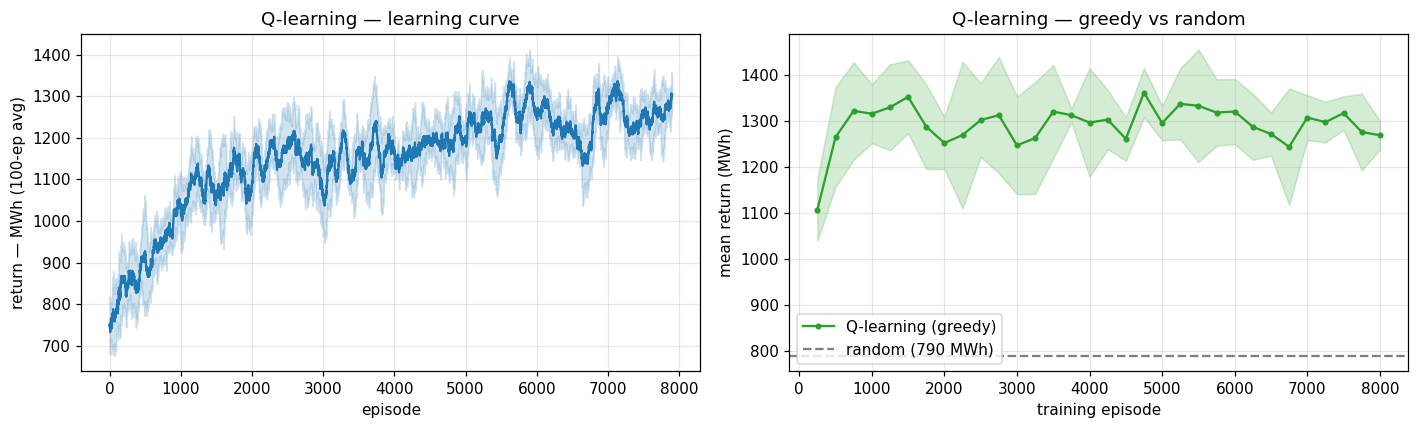

Q-table coverage: 6577 / 26244 = 25.1% of states ever visited


In [6]:
sm = np.array([moving_average(c) for c in tab_curves]); m, sd = sm.mean(0), sm.std(0); x = np.arange(sm.shape[1])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(x, m * MW, color="C0"); a1.fill_between(x, (m - sd) * MW, (m + sd) * MW, color="C0", alpha=0.2)
a1.set_xlabel("episode"); a1.set_ylabel("return — MWh (100-ep avg)"); a1.set_title("Q-learning — learning curve"); a1.grid(alpha=0.3)
em, es = tab_evals.mean(0), tab_evals.std(0)
a2.plot(tab_x, em * MW, "o-", color="C2", ms=3, label="Q-learning (greedy)")
a2.fill_between(tab_x, (em - es) * MW, (em + es) * MW, color="C2", alpha=0.2)
a2.axhline(rand_m * MW, ls="--", color="C7", label=f"random ({rand_m*MW:.0f} MWh)")
a2.set_xlabel("training episode"); a2.set_ylabel("mean return (MWh)"); a2.set_title("Q-learning — greedy vs random"); a2.legend(); a2.grid(alpha=0.3)
fig.tight_layout(); plt.show()

frac = np.array(tab_cov).mean() / env.n_states
print(f"Q-table coverage: {np.array(tab_cov).mean():.0f} / {env.n_states} = {frac:.1%} of states ever visited")

**Result.** Tabular Q-learning learns a diversifying policy and beats random — but the
table is already largely **empty** (only about a quarter of the 26,244 states are ever
visited). Every unvisited cell gets *no* learning: a table cannot generalise from a state
to a similar one. That is the curse of dimensionality, and the case for the next method.

## 2 · Linear function approximation (hand-crafted features)

Instead of a table, we approximate the value as a **linear function of hand-crafted
features**: $q(s,a) = \mathbf{w}_a \cdot \mathbf{x}(s)$, one weight vector per action,
updated by **semi-gradient** Q-learning (the lecture's `LinearQLearningAgent`). The
features $\mathbf{x}(s)$ summarise the state in a handful of numbers that **generalise**
across the 26,244 states — the agent no longer needs to visit each one.

Our feature vector (18 numbers): a **bias**, the **surplus**, a one-hot of the **demand
phase**, the **per-line suspicion** $\sigma_c$, and the **per-line slack** in the current
phase. Because each action has its own weights, action *"overdraw C4"* can learn to lower
its value when C4's suspicion feature is high — the diversification behaviour, learned
from features rather than memorised per state.

In [7]:
class L2Features:
    """Hand-crafted state features for Level 2 (decodes the integer observation)."""
    def __init__(self, env):
        self.env = env
        self.n_features = 1 + 1 + env.n_phase + env.n_consumers + env.n_consumers
    def __call__(self, obs):
        phase, surplus, susp = self.env.decode(int(obs))
        slack = self.env.slack[phase]
        return np.concatenate([
            [1.0],                                    # bias
            [surplus / self.env.surplus_max],         # surplus
            np.eye(self.env.n_phase)[phase],          # demand-phase one-hot
            susp / max(1, self.env.k - 1),            # per-line suspicion
            slack / max(1, self.env.slack.max()),     # per-line slack (this phase)
        ])

print("features per state:", L2Features(env).n_features, " x", env.n_actions, "actions =",
      L2Features(env).n_features * env.n_actions, "weights (vs 26,244 x 13 table cells)")

features per state: 18  x 13 actions = 234 weights (vs 26,244 x 13 table cells)


In [8]:
def train_lin(env, n_episodes, seed, eval_env, eval_every=250, eval_episodes=50):
    agent = LinearQLearningAgent(L2Features(env), env.n_actions, alpha=0.01, gamma=0.99, epsilon_decay=0.9995, seed=seed)
    returns = np.empty(n_episodes); eval_x, eval_y = [], []
    for ep in range(n_episodes):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            a = agent.select_action(s); s2, r, term, trunc, _ = env.step(a)
            agent.update(s, a, r, s2, term); s, g, done = s2, g + r, term or trunc
        returns[ep] = g; agent.end_episode()
        if (ep + 1) % eval_every == 0:
            m, _ = evaluate(eval_env, agent, eval_episodes); eval_x.append(ep + 1); eval_y.append(m)
    return agent, returns, np.array(eval_x), np.array(eval_y)

lin_curves, lin_evals, lin_agents = [], [], []
lin_x = None
for seed in SEEDS:
    ag, ret, ex, ey = train_lin(GridThiefEnvL2(seed=1), N_EPISODES, seed, GridThiefEnvL2(seed=1))
    lin_curves.append(ret); lin_evals.append(ey); lin_agents.append(ag); lin_x = ex
lin_curves = np.array(lin_curves); lin_evals = np.array(lin_evals)
lin_final = lin_evals.mean(0)[-1]
print(f"linear FA greedy: {lin_final*MW:+.0f} MWh")

linear FA greedy: +1434 MWh


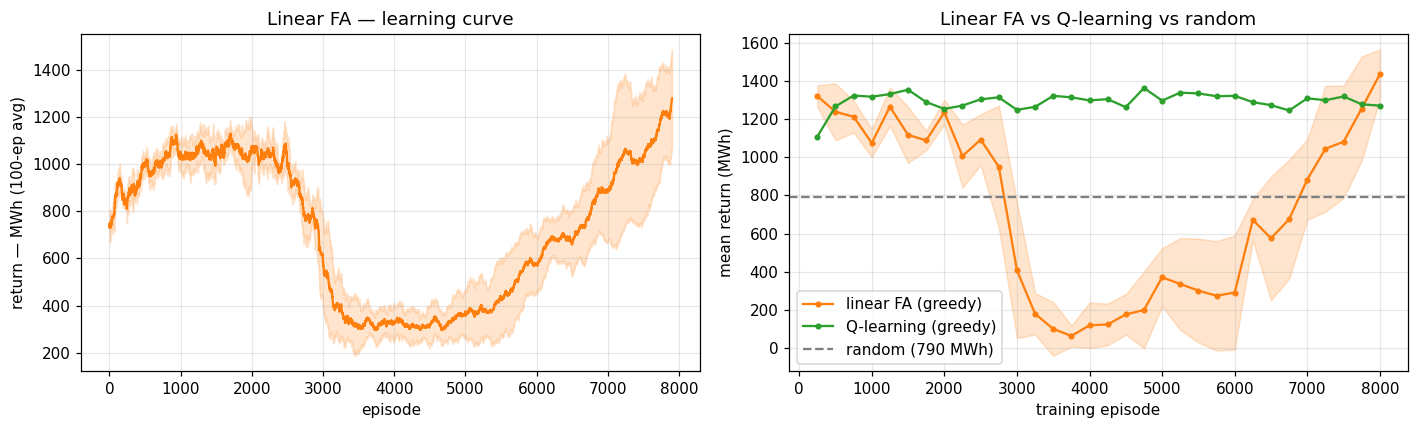

In [9]:
sm = np.array([moving_average(c) for c in lin_curves]); m, sd = sm.mean(0), sm.std(0); x = np.arange(sm.shape[1])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(x, m * MW, color="C1"); a1.fill_between(x, (m - sd) * MW, (m + sd) * MW, color="C1", alpha=0.2)
a1.set_xlabel("episode"); a1.set_ylabel("return — MWh (100-ep avg)"); a1.set_title("Linear FA — learning curve"); a1.grid(alpha=0.3)
em, es = lin_evals.mean(0), lin_evals.std(0)
a2.plot(lin_x, em * MW, "o-", color="C1", ms=3, label="linear FA (greedy)")
a2.fill_between(lin_x, (em - es) * MW, (em + es) * MW, color="C1", alpha=0.2)
a2.plot(tab_x, tab_evals.mean(0) * MW, "o-", color="C2", ms=3, label="Q-learning (greedy)")
a2.axhline(rand_m * MW, ls="--", color="C7", label=f"random ({rand_m*MW:.0f} MWh)")
a2.set_xlabel("training episode"); a2.set_ylabel("mean return (MWh)"); a2.set_title("Linear FA vs Q-learning vs random"); a2.legend(); a2.grid(alpha=0.3)
fig.tight_layout(); plt.show()

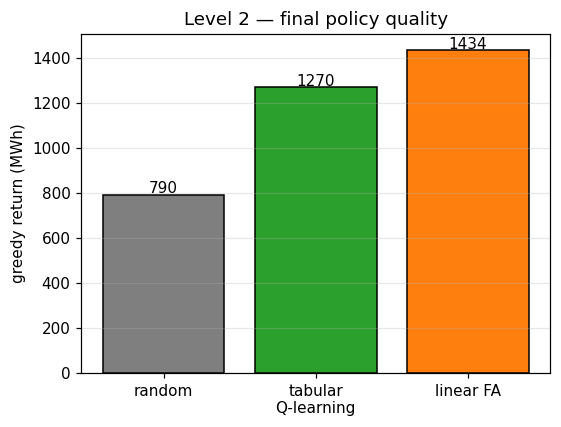

In [10]:
labels = ["random", "tabular\nQ-learning", "linear FA"]
vals = [rand_m * MW, tab_final * MW, lin_final * MW]
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(labels, vals, color=["C7", "C2", "C1"], edgecolor="black")
for i, v in enumerate(vals): ax.text(i, v + 8, f"{v:.0f}", ha="center")
ax.set_ylabel("greedy return (MWh)"); ax.set_title("Level 2 — final policy quality")
ax.grid(axis="y", alpha=0.3); plt.show()

**Result.** Linear FA **matches or beats** tabular Q-learning on Level 2 — with only
$18\times13 = 234$ weights instead of a 341,000-cell table, and with **no** empty regions.
By learning from features that summarise the state, it **generalises** across the many
near-identical $(\phi, U, \sigma)$ combinations the table had to memorise one by one. This
is exactly why function approximation is the right tool once the state space explodes.

## Watch a heist, step by step

A greedy episode of the **linear-FA** agent. The tapped line is highlighted (green skim /
orange overdraw), each consumer box is shaded by its **suspicion** ($\sigma$ at right), the
**surplus gauge** fills and empties, and an **ALARM** wipes it. Watch it rotate across
edges so none stays hot, and favour S1 over the more-watched S2.

In [11]:
import matplotlib.animation as animation
from IPython.display import HTML

def draw_scene(ax, env, snap):
    ax.clear(); n = env.n_consumers
    ax.set_xlim(0, 11); ax.set_ylim(0, n + 2.2); ax.axis("off")
    phase, U = snap["phase"], snap["surplus"]; tapped, ov, alarm = snap["tapped"], snap["overdraw"], snap["alarm"]
    susp = snap.get("susp"); subof = getattr(env, "substation_of", None)
    slack = env.slack[phase]; smax = max(1, int(env.slack.max())); ymid = (n + 2.2) / 2
    def box(x, y, w, h, label, fc, ec="black", lw=1.1, fs=8):
        ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.03", fc=fc, ec=ec, lw=lw))
        ax.text(x, y, label, ha="center", va="center", fontsize=fs, weight="bold")
    box(1.0, ymid, 1.4, 1.0, "Plant", "#dbe9f6"); hub_x = 3.9
    sub_y = {}
    for s in range(env.n_substations):
        members = [i for i in range(n) if subof[i] == s]
        sy = float(np.mean([n - i + 0.9 for i in members])); sub_y[s] = sy
        box(hub_x, sy, 1.5, 1.0, f"{env.substations[s]}\n(x{env.substation_sens[s]:g})", "#eef3f8")
        ax.annotate("", xy=(hub_x - 0.8, sy), xytext=(1.72, ymid), arrowprops=dict(arrowstyle="-|>", lw=2.0, color="#4a6fa5"))
    green = plt.get_cmap("Greens")
    for i in range(n):
        y = n - i + 0.9; sy = sub_y[subof[i]]; hl = (i == tapped)
        ecol = ("#e6550d" if ov else "#2ca25f") if hl else green(0.25 + 0.6 * slack[i] / smax)
        ax.annotate("", xy=(8.15, y), xytext=(hub_x + 0.8, sy), arrowprops=dict(arrowstyle="-|>", lw=4.0 if hl else 1.6, color=ecol))
        cfc = plt.get_cmap("OrRd")(0.15 + 0.5 * susp[i] / max(1, env.k - 1))
        if hl and alarm: cfc = "#ff8a8a"
        box(8.9, y, 1.5, 0.72, env.consumers[i], cfc)
        ax.text(6.5, y + 0.16, f"{slack[i]*MW} MW", fontsize=7, color="#444", ha="center")
        ax.text(10.0, y, f"σ{susp[i]}", fontsize=7, color="#a33", va="center")
        if hl: ax.text(6.5, y - 0.24, "OVERDRAW" if ov else "SKIM", fontsize=8, weight="bold", color=ecol, ha="center")
    barx, barw = 2.2, 6.2
    ax.text(0.2, 0.55, "surplus", fontsize=9, va="center")
    ax.add_patch(Rectangle((barx, 0.35), barw, 0.5, fill=False, ec="black"))
    ax.add_patch(Rectangle((barx, 0.35), barw * U / env.surplus_max, 0.5, fc="#4a90d9"))
    ax.text(barx + barw + 0.25, 0.6, f"{U*MW}/{env.surplus_max*MW} MW", va="center", fontsize=9)
    ax.text(hub_x, n + 1.9, f"demand phase {phase}   (sensitivity {env.sens[phase]:.2f})", ha="center", fontsize=8, color="#555")
    if alarm:
        ax.text(5.5, ymid + 1.4, "ALARM — surplus wiped", ha="center", fontsize=13, weight="bold", color="white", bbox=dict(boxstyle="round", fc="#d62728", ec="none"))

def rollout(env, agent, seed=7):
    s, _ = env.reset(seed=seed)
    snaps = [dict(step=0, action=None, reward=0.0, ret=0.0, phase=env.phase, surplus=env.surplus, tapped=-1, overdraw=False, alarm=False, susp=env.susp.copy())]
    ret = 0.0
    for t in range(env.max_steps):
        a = agent.select_action(s, greedy=True)
        s, r, term, trunc, info = env.step(a); ret += r
        snaps.append(dict(step=t+1, action=a, reward=r, ret=ret, phase=info["phase"], surplus=info["surplus"],
                          tapped=info["tapped"], overdraw=(a % 2 == 1 and a != env.LIE_LOW), alarm=info["alarm"], susp=info["suspicion"].copy()))
        if term or trunc: break
    return snaps

viz_env = GridThiefEnvL2(seed=1)
snaps = rollout(viz_env, lin_agents[0])
fig, ax = plt.subplots(figsize=(8.5, 4.6))
def upd(i):
    draw_scene(ax, viz_env, snaps[i]); s = snaps[i]
    an = "start" if s["action"] is None else ACTION_NAMES_L2[s["action"]]
    ax.set_title(f"step {s['step']} | {an} | reward={s['reward']*MW:.0f} MW | return={s['ret']*MW:.0f} MWh", fontsize=10)
ani = animation.FuncAnimation(fig, upd, frames=len(snaps), interval=350)
plt.close(fig)
HTML(ani.to_jshtml(fps=3))

## Takeaways

- **Tabular Q-learning strains on Level 2:** it learns, but only ~25% of the 26,244-state
  table is ever visited — the curse of dimensionality — and the rest stays unlearned.
- **Linear function approximation matches/beats it with a handful of weights**, by learning
  the value from **hand-crafted features** that *generalise* across near-identical states
  instead of memorising each. This is the intended Level-2 method.
- **Next (Level 3):** continuous flows + hidden suspicion (partial observability). There,
  even linear features saturate — the value depends on an *unobservable* state — pointing to
  a **DQN**.